In [77]:
%matplotlib inline

import pandas as pd

r = pd.read_csv( 'ratings.csv' )
tr = pd.read_csv( 'to_read.csv' )
b = pd.read_csv( 'books.csv' )

t = pd.read_csv( 'tags.csv' )
bt = pd.read_csv( 'book_tags.csv')


### Ratings

In [78]:
r.head()

,user_id,book_id,rating
0,1,258,5
1,2,4081,4
2,2,260,5
3,2,9296,5
4,2,2318,3


Ratings are sorted chronologically, oldest first.

In [79]:
len(r)

5976479

<Axes: >

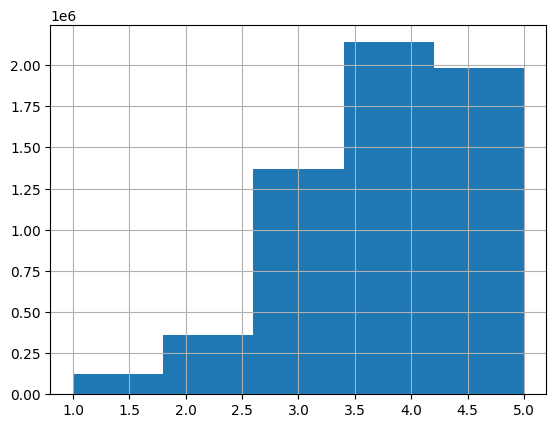

In [80]:
r.rating.hist( bins = 5 )

It appears that 4 is the most popular rating. There are relatively few ones and twos.

### To read
These are the books users marked "to read".


In [81]:
tr.head()

,user_id,book_id
0,9,8
1,15,398
2,15,275
3,37,7173
4,34,380


In [82]:
len(tr)

912705

Most books have been marked to read by somebody. Majority of the users have some books marked to read.

In [83]:
len(tr.book_id.unique())

9986

In [84]:
len(tr.user_id.unique())

48871

### Books

In [85]:
b.head()

,book_id,goodreads_book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,...,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,...,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...


Books are sorted by their popularity, as measured by number of ratings (overall, not in this dataset).

In [86]:
len(b)

10000

### User and book IDs

In [87]:
r.user_id.max()

np.int64(53424)

In [88]:
r.book_id.max()

np.int64(10000)

The IDs are contiguous.

In [89]:
assert( len( r.user_id.unique()) == r.user_id.max())
assert( len( r.book_id.unique()) == r.book_id.max())

### Reviews per book

Most books have a few hundred reviews, but some have as few as eight.

In [90]:
reviews_per_book = r.groupby( 'book_id' ).book_id.apply( lambda x: len( x ))
reviews_per_book.describe()

count    10000.000000
mean       597.647900
std       1267.289788
min          8.000000
25%        155.000000
50%        248.000000
75%        503.000000
max      22806.000000
Name: book_id, dtype: float64

In [91]:
reviews_per_book.sort_values().head( 10 )

book_id
7803     8
9345    11
9486    24
1935    33
9315    36
9553    41
8181    45
9260    48
9479    48
9705    50
Name: book_id, dtype: int64

### Reviews per user

All users have at least 19 reviews.

In [92]:
reviews_per_user = r.groupby( 'user_id' ).user_id.apply( lambda x: len( x ))
reviews_per_user.describe()

count    53424.000000
mean       111.868804
std         26.071224
min         19.000000
25%         96.000000
50%        111.000000
75%        128.000000
max        200.000000
Name: user_id, dtype: float64

In [93]:
reviews_per_user.sort_values().head( 10 )

user_id
34590    19
43675    20
40753    21
51725    21
32128    21
42736    22
25856    22
38280    22
50918    22
40299    22
Name: user_id, dtype: int64

### Tags

In [94]:
t.head()

,tag_id,tag_name
0,0,-
1,1,--1-
2,2,--10-
3,3,--12-
4,4,--122-


In [95]:
len(t)

34252

In [96]:
bt.head()

,goodreads_book_id,tag_id,count
0,1,30574,167697
1,1,11305,37174
2,1,11557,34173
3,1,8717,12986
4,1,33114,12716


Tag applications are sorted by goodreads_book_id ASC and by count DESC.

In [97]:
len(bt)

999912

Let us merge tag names into tag applications.

In [98]:
bt = bt.merge( t, on = 'tag_id' )

Why don't we merge book titles for good measure.

In [99]:
bt = bt.merge( b[[ 'goodreads_book_id', 'title']], on = 'goodreads_book_id' )

It appears that there are some negative tag counts. Let's fix this.

In [100]:
bt['count'].describe()

count    999912.000000
mean        208.869633
std        3501.265173
min          -1.000000
25%           7.000000
50%          15.000000
75%          40.000000
max      596234.000000
Name: count, dtype: float64

In [101]:
bt.loc[ bt['count'] < 0, 'count'] = 0

Sample some popular book tags.

In [102]:
bt.sample( 10, weights = 'count')

,goodreads_book_id,tag_id,count,tag_name,title
92200,11275,30574,103218,to-read,The Wind-Up Bird Chronicle
379600,125963,30574,1380,to-read,Thr3e
887794,17325147,30574,21206,to-read,"Left Drowning (Left Drowning, #1)"
954356,22571552,30574,43491,to-read,So You've Been Publicly Shamed
753694,9520360,30574,84525,to-read,"The Son of Neptune (The Heroes of Olympus, #2)"
777132,10799881,33035,21,ya-paranormal,"Underworld (Abandon, #2)"
995112,29056083,30574,248603,to-read,Harry Potter and the Cursed Child - Parts One ...
257602,49041,11305,10301,fantasy,"New Moon (Twilight, #2)"
78900,9762,30574,5802,to-read,Loving What Is: Four Questions That Can Change...
946859,21535271,11557,693,favorites,The Slow Regard of Silent Things (The Kingkill...


These are the most popular tags:

In [103]:
tag_counts = bt.groupby( 'tag_name' ).tag_name.count().sort_values( ascending = False )
tag_counts.head( 20 )

tag_name
to-read              9983
favorites            9881
owned                9858
books-i-own          9799
currently-reading    9776
library              9415
owned-books          9221
fiction              9097
to-buy               8692
kindle               8316
default              8239
ebook                8054
my-books             7561
audiobook            7242
ebooks               7203
wish-list            7192
my-library           7000
audiobooks           6862
i-own                6670
adult                6604
Name: tag_name, dtype: int64

In [104]:
b.head(100)

,book_id,goodreads_book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,...,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,...,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,13536860,13536860,18034963,133,345803507,9.780346e+12,E.L. James,2012.0,Fifty Shades Freed,...,387290,610116,25287,39079,55691,109963,140304,265079,https://images.gr-assets.com/books/1336418837m...,https://images.gr-assets.com/books/1336418837s...
96,97,17245,17245,3165724,2207,393970124,9.780394e+12,"Bram Stoker, Nina Auerbach, David J. Skal",1897.0,Dracula,...,618973,689739,17263,11756,36719,151396,246043,243825,https://images.gr-assets.com/books/1387151694m...,https://images.gr-assets.com/books/1387151694s...
97,98,5060378,5060378,6976108,209,307269981,9.780307e+12,"Stieg Larsson, Reg Keeland",2006.0,Flickan som lekte med elden,...,563994,649253,31423,4623,15781,91021,258236,279592,https://images.gr-assets.com/books/1351778881m...,https://images.gr-assets.com/books/1351778881s...
98,99,11857408,11857408,16813814,147,1612130585,9.781612e+12,E.L. James,2011.0,Fifty Shades Darker,...,552059,623340,28052,37245,58935,114203,150906,262051,https://images.gr-assets.com/books/1358266080m...,https://images.gr-assets.com/books/1358266080s...


In [105]:
b.head(20)

,book_id,goodreads_book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,...,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,...,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...
5,6,11870085,11870085,16827462,226,525478817,9.780525e+12,John Green,2012.0,The Fault in Our Stars,...,2346404,2478609,140739,47994,92723,327550,698471,1311871,https://images.gr-assets.com/books/1360206420m...,https://images.gr-assets.com/books/1360206420s...
6,7,5907,5907,1540236,969,618260307,9.780618e+12,J.R.R. Tolkien,1937.0,The Hobbit or There and Back Again,...,2071616,2196809,37653,46023,76784,288649,665635,1119718,https://images.gr-assets.com/books/1372847500m...,https://images.gr-assets.com/books/1372847500s...
7,8,5107,5107,3036731,360,316769177,9.780317e+12,J.D. Salinger,1951.0,The Catcher in the Rye,...,2044241,2120637,44920,109383,185520,455042,661516,709176,https://images.gr-assets.com/books/1398034300m...,https://images.gr-assets.com/books/1398034300s...
8,9,960,960,3338963,311,1416524797,9.781417e+12,Dan Brown,2000.0,Angels & Demons,...,2001311,2078754,25112,77841,145740,458429,716569,680175,https://images.gr-assets.com/books/1303390735m...,https://images.gr-assets.com/books/1303390735s...
9,10,1885,1885,3060926,3455,679783261,9.780680e+12,Jane Austen,1813.0,Pride and Prejudice,...,2035490,2191465,49152,54700,86485,284852,609755,1155673,https://images.gr-assets.com/books/1320399351m...,https://images.gr-assets.com/books/1320399351s...


In [106]:
books = b[["authors", "original_title", "image_url", "small_image_url", "original_publication_year"]]
books.head(100)

,authors,original_title,image_url,small_image_url,original_publication_year
0,Suzanne Collins,The Hunger Games,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...,2008.0
1,"J.K. Rowling, Mary GrandPré",Harry Potter and the Philosopher's Stone,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...,1997.0
2,Stephenie Meyer,Twilight,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...,2005.0
3,Harper Lee,To Kill a Mockingbird,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...,1960.0
4,F. Scott Fitzgerald,The Great Gatsby,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...,1925.0
...,...,...,...,...,...
95,E.L. James,Fifty Shades Freed,https://images.gr-assets.com/books/1336418837m...,https://images.gr-assets.com/books/1336418837s...,2012.0
96,"Bram Stoker, Nina Auerbach, David J. Skal",Dracula,https://images.gr-assets.com/books/1387151694m...,https://images.gr-assets.com/books/1387151694s...,1897.0
97,"Stieg Larsson, Reg Keeland",Flickan som lekte med elden,https://images.gr-assets.com/books/1351778881m...,https://images.gr-assets.com/books/1351778881s...,2006.0
98,E.L. James,Fifty Shades Darker,https://images.gr-assets.com/books/1358266080m...,https://images.gr-assets.com/books/1358266080s...,2011.0


In [107]:

import numpy as np

books["publication_year"] = books["original_publication_year"].fillna(np.nan).astype("Int64").astype(str)

C:\Users\AD9F95\AppData\Local\Temp\ipykernel_5984\659620857.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  books["publication_year"] = books["original_publication_year"].fillna(np.nan).astype("Int64").astype(str)


In [123]:
books_200 = books.head(200)

In [124]:

formatted_json = books_200.to_json(orient='index', force_ascii=False).replace('\\/', '/')

In [125]:
print(formatted_json, file=open('books_max.json', 'w', encoding="utf-8"))
